## Imports

In [1]:
import sys
import os

module_path = os.path.abspath(os.path.join('..', 'src'))
sys.path.insert(0, module_path)

In [2]:
import pandas as pd
import plotly.express as px
import numpy as np
import json

from src.analysis.converters import convert_transitions_to_state_counts
from src.models.seir import SEIRNeighborsFSMAgent

## Load data

In [3]:
sim_dt = "2025-10-04-233644Z"
sim_data_filename = f"../simulation_data/SEIR_Neighbors_Simulation_Transitions-{sim_dt}.csv"
sim_params_filename = f"../simulation_data/SEIR_Neighbors_Simulation_Params-{sim_dt}.json"

In [4]:
with open(sim_params_filename, "r") as file:
    sim_params = json.load(file)
sim_params

{'random_seed': 42,
 'n_agents': 1000,
 'sim_duration': 365,
 'output_path': 'simulation_data',
 'initially_infected': 50,
 'beta': 0.01,
 'gamma': 0.01,
 'sigma': 0.05,
 'e1': 1,
 'e2': 3,
 't1': 7,
 't2': 14,
 'simulation_start': '2025-10-04-233642Z',
 'simulation_end': '2025-10-04-233644Z',
 'simulation_duration_seconds': 2.051383,
 'agent_class': 'SEIRNeighborsFSMAgent'}

In [5]:
transitions_df = pd.read_csv(sim_data_filename)
transitions_df.head()

,time,agent,event,source_state,dest_state
0,0,654,transition,susceptible,infected
1,0,114,transition,susceptible,infected
2,0,25,transition,susceptible,infected
3,0,759,transition,susceptible,infected
4,0,281,transition,susceptible,infected


In [6]:
states = [state.name for state in SEIRNeighborsFSMAgent.states]

In [17]:
 df = convert_transitions_to_state_counts(transitions_df=transitions_df,
                                          states=states,
                                          initial_state=states[0],
                                          n_agents=sim_params['n_agents'],
                                          sim_duration=sim_params['sim_duration'])

## Simulation Params

In [19]:
N_AGENTS = sim_params['n_agents']
BETA = sim_params['beta']
GAMMA = sim_params['gamma']
SIM_DURATION = sim_params['sim_duration']

## Visualization

### Style

In [20]:
color_map = {"susceptible": "#8da0cb", "infected": "#fc8d62", "recovered": "#66c2a5"}
title_text = f"SEIR Neighbor Agent Model<br>β={BETA}, γ={GAMMA}, Population Size={N_AGENTS}"

legend_params = dict(
    orientation="h",
    yanchor="bottom",
    y=-.3,
    xanchor="center",
    x=0.5,
    title_text="")

title_params = dict(text=title_text, font_size=20)

graph_params = dict(
    title=title_params,
    legend=legend_params,
    width=1000,
    height=500,
    template="presentation")

### Area Plot

In [24]:
groups = [g for g in df.columns if g != 'time']

timeline_df = (
    df
    .melt(id_vars=['time'], value_vars=groups, var_name="grp", value_name="count")
    .assign(grp=lambda _df: pd.Categorical(_df.grp, categories=groups, ordered=True))
    .sort_values(by=["time", "grp"], ascending=[True, False])
    .reset_index(drop=True)
)
df.head(5)

,time,susceptible,exposed,infected,recovered
0,0,950,0,50,0
1,1,935,15,50,0
2,2,924,22,54,0
3,3,904,33,63,0
4,4,892,31,77,0


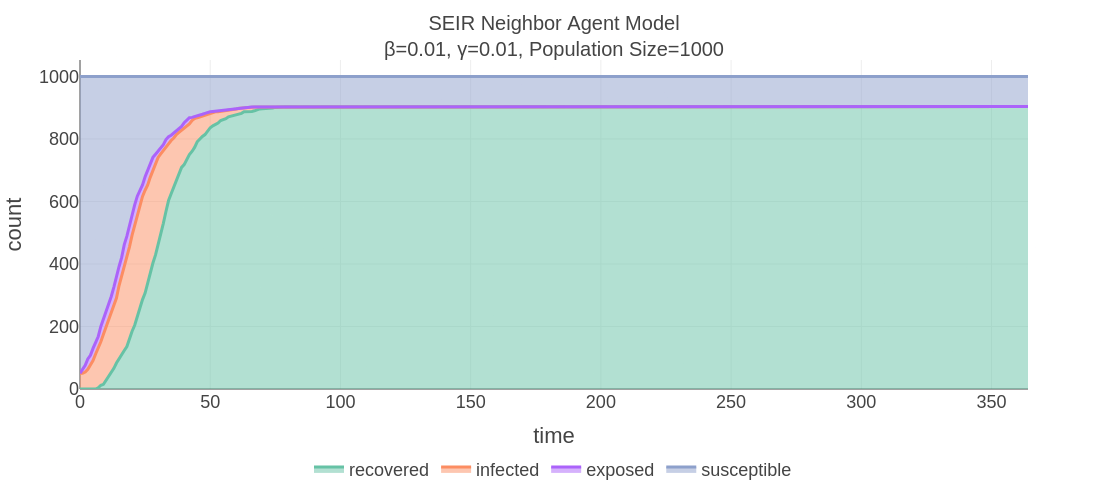

In [25]:
fig = px.area(timeline_df, x="time", y="count", color="grp", color_discrete_map=color_map)
fig.update_layout(**graph_params)
fig.show()

### Line Plot

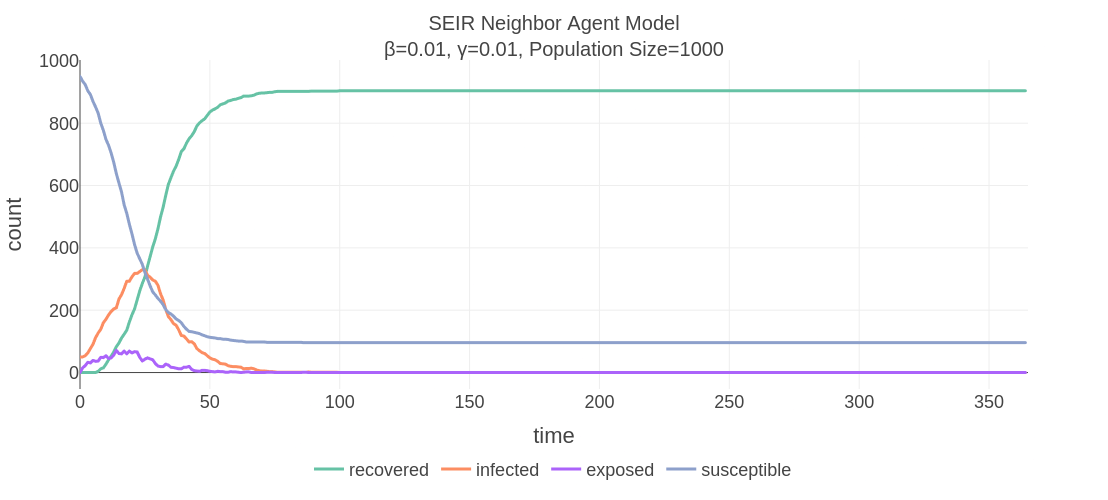

In [26]:
fig = px.line(timeline_df, x="time", y="count", color="grp", color_discrete_map=color_map)
fig.update_layout(**graph_params, xaxis_range=[0, 365])
fig.show()

### Line plot animated

In [46]:
df2 = (
    df
    .sort_values(by=["time"])
    .reset_index(drop=True)
    .head(100)
)

In [53]:
def create_animation_df(source_df, start=10, frame_cnt=SIM_DURATION, speed_up=1):
    target_df = pd.DataFrame()
    frame_cnt = int(frame_cnt / speed_up)
    for i in np.arange(start, frame_cnt):
        dfa = source_df.head(i * speed_up).copy()
        dfa['ix'] = i
        target_df = pd.concat([target_df, dfa])
    return target_df

In [56]:
animation_df = create_animation_df(df2, start=0, frame_cnt=df2.shape[0], speed_up=1)

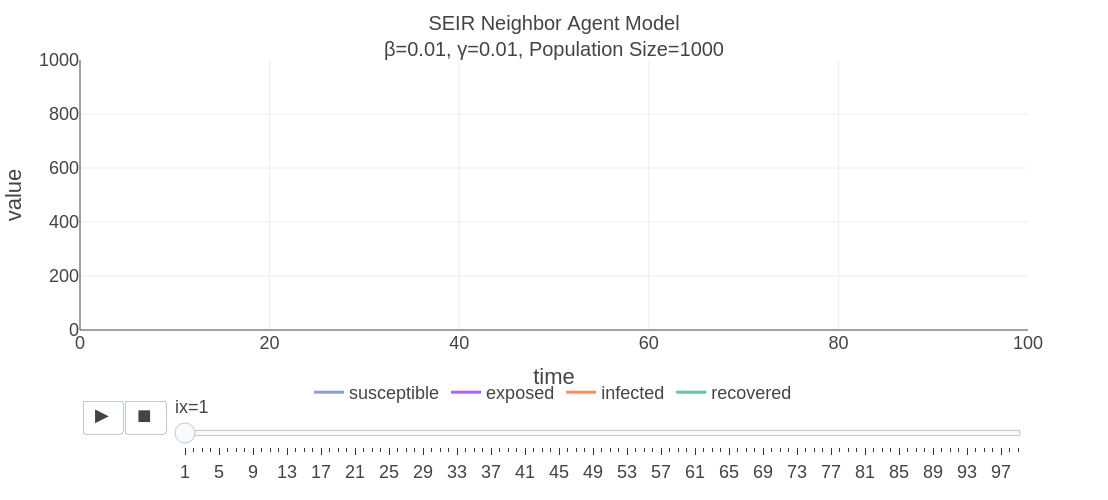

In [58]:
fig = px.line(animation_df,
              x="time",
              y=groups,
              animation_frame="ix",
              color_discrete_map=color_map)
fig.update_layout(**graph_params, xaxis_range=[0, 100], yaxis_range=[0, 1000])
fig.layout.updatemenus[0].buttons[0]['args'][1]['frame']['redraw'] = True
fig.show()